In [1]:
from stitch2d import StructuredMosaic, create_mosaic, OpenCVTile
import tile as tile_memmap
import mosaic as mosaic_memmap
from tile import Tile
import os
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import rasterio
import re

tile_path = "C:\\Users\\chloe\\wolkovich_s24\\TreeRings\\code\\focus_testng\\jul12_almostfullcookie"
tile_path = "C:\\Users\\honey\\Downloads\\querob_jul16"

os.path.exists(tile_path)

ImportError: cannot import name 'Tile' from 'tile' (c:\Users\honey\OneDrive\Desktop\TreeRings\code\image_stitch_testing\stitch2d\tile.py)

In [2]:
# Define the directory containing the files
directory = tile_path

# Create a regex pattern to match the filenames and extract row and column numbers
pattern = re.compile(r'focused_(\d+)_(\d+)')

# List all files in the directory
files = os.listdir(directory)

# Filter and sort the files based on the row and column numbers
sorted_files = sorted(
    (f for f in files if pattern.match(f)),
    key=lambda f: (int(pattern.match(f).group(1)), int(pattern.match(f).group(2)))
)

# # Print the sorted list of files
# for file in sorted_files:
#     print(file)


In [3]:
memmaps = []
tiles = []
i = 0
for dir, _, files in os.walk(tile_path):
    for file in sorted_files:
        compressed_path = os.path.join(dir, file)
        dir_dat = "./dats/"
        with rasterio.open(compressed_path) as dataset:
            memmap_array = np.memmap(dir_dat + "{}_".format(i) + "memmap_array.dat", dtype=dataset.dtypes[0], mode='w+', shape=(dataset.height, dataset.width, dataset.count))
            i+=1
            inter = dataset.read()
            memmap_array[:] = np.transpose(inter, (1, 2, 0))
            memmaps.append(memmap_array)

            
        

c:\Users\honey\anaconda3\envs\stitch2d\Lib\site-packages\rasterio\__init__.py:317: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [4]:
tiles = []
for memmap in memmaps:
    tiles.append(tile_memmap.OpenCVTile(memmap))

#tiles_np = np.array(tiles).reshape((27, -1))

In [9]:
mosaic = mosaic_memmap.StructuredMosaic(tiles, dim=50)

In [10]:
mosaic.align()

In [12]:
mosaic.save_params("test_3.json")

In [13]:
mosaic.save("this_doesnt_save.tiff")

SAVING
SAVING BIG MEMMAP
In draw memmap tile count 1033
LARGE MATRIX SHAPE: [62328, 79244, 3]


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:798: error: (-215:Assertion failed) !_img.empty() in function 'cv::imwrite'


In [15]:
stitch = np.memmap("large_matrix.dat", dtype='uint8', mode='r', shape=(62328, 79244, 3))

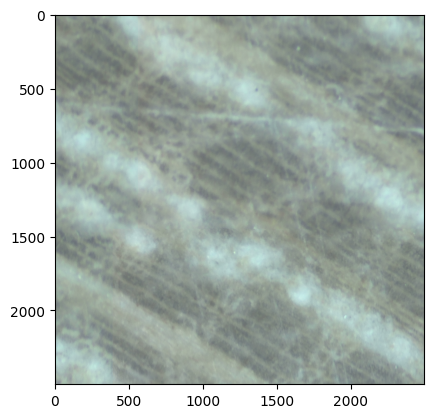

In [23]:
width = 2500         
height= 2500

tl_coord = (25000, 15000)

view = stitch[tl_coord[0]: tl_coord[0] + width, tl_coord[1]:tl_coord[1] + height]
plt.imshow(np.array(view))
plt.show()

In [3]:
mosaic = create_mosaic(
    tile_path,
    dim=27,                  # number of tiles in primary axis
    origin="upper left",     # position of first tile
    direction="horizontal",  # primary axis (i.e., the direction to traverse first)
    pattern="raster"          # snake or raster
  )

In [4]:

mosaic.downsample(0.6)
mosaic.align()
mosaic.save("mosaic_full_downscaled.tiff")
mosaic.reset_tiles()
mosaic.save_params()

mosaic.smooth_seams()


In [5]:
mosaic.save("mosaic_full.tiff")